In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('historical_data.csv')
print(df.shape)
print(df.dtypes)
print(df['Timestamp IST'].head())
print(df['Account'].nunique())
print(df['Coin'].nunique())
print(df['Side'].unique())
print(df['Direction'].unique())

(211224, 16)
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: str
32
246
<StringArray>
['BUY', 'SELL']
Length: 2, dtype: str
<StringArray>
[                      'Buy',                      'Sell',
                 'Open Long',                'Close Long',
      'Spot Dust Conversion',                'Open Short',
               'Close Short',              'Long > Short',
              'Short > Long',         'Auto-Deleveraging',
 'Liquidated Is

In [3]:
sns.set_style('whitegrid')
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format = '%d-%m-%Y %H:%M')
trades['Date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

merged = trades.merge(sentiment[['date', 'classification', 'value']], left_on = 'Date', right_on='date',how='left')

print("Trades with no matching sentiment date:", merged['classification'].isna().sum(), "/", len(merged))
merged.to_csv('merged_trades.csv', index=False)
print(merged[['Date', 'classification','value']].head())
print(merged['classification'].value_counts())

Trades with no matching sentiment date: 6 / 211224


         Date classification  value
0  2024-12-02  Extreme Greed   80.0
1  2024-12-02  Extreme Greed   80.0
2  2024-12-02  Extreme Greed   80.0
3  2024-12-02  Extreme Greed   80.0
4  2024-12-02  Extreme Greed   80.0
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [4]:
sns.set_style('whitegrid')
merged = pd.read_csv('merged_trades.csv')

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories = order, ordered = True)
merged[['Date', 'classification', 'value']].head()

summary = merged.groupby('classification').agg(total_trades=('Closed PnL', 'count'),total_volume_usd=('Size USD', 'sum'),avg_trade_size_used=('Size USD','mean'),
                                               total_pnl=('Closed PnL', 'sum'),avg_pnl=('Closed PnL', 'mean'),
                                               win_rate=('Closed PnL', lambda x: (x> 0).mean() * 100),
                                              ).round(2)
print("===Summary By Sentiment ===")
print(summary)
summary.to_csv('summary_by_sentiment.csv')

closed = merged[merged['Closed PnL'] != 0].copy()
closed_summary = closed.groupby('classification').agg(
    closed_trades=('Closed PnL', 'count'),
    avg_pnl_per_closed=('Closed PnL', 'mean'),
    win_rate_pct=('Closed PnL', lambda x: (x > 0).mean() * 100),
    total_pnl=('Closed PnL', 'sum'),
).round(2)
print("\n=== Closed-Trade Summary by Sentiment ===")
print(closed_summary)
closed_summary.to_csv('closed_summary_by_sentiment.csv')


side_dist = pd.crosstab(merged['classification'], merged['Side'], normalize='index') * 100
print("\n === Buy vs Sell % by Sentiment ===")
print(side_dist.round(1))
side_dist.to_csv('side_distribution.csv')

liq = merged[merged['Direction'].str.contains('liquidat', na = False)]
liq_counts = liq.groupby('classification').size()
total_counts = merged.groupby('classification').size()
liq_rate = (liq_counts / total_counts * 100).round(3)
print("\n=== Liquidation rate (%) by sentiment ===")
print(liq_rate)

acct_sent = merged.groupby(['Account', 'classification'])['Size USD'].mean().reset_index()
acct_pivot = acct_sent.pivot(index = 'Account', columns='classification', values='Size USD')
print("\n === Sample: Avg trade size per account across sentiment (dirst 5 accounts) ===")
print(acct_pivot.head())



===Summary By Sentiment ===
                total_trades  total_volume_usd  avg_trade_size_used  \
classification                                                        
Extreme Fear           21400      1.144843e+08              5349.73   
Fear                   61837      4.833248e+08              7816.11   
Neutral                37686      1.802421e+08              4782.73   
Greed                  50303      2.885825e+08              5736.88   
Extreme Greed          39992      1.244652e+08              3112.25   

                 total_pnl  avg_pnl  win_rate  
classification                                 
Extreme Fear     739110.25    34.54     37.06  
Fear            3357155.44    54.29     42.08  
Neutral         1292920.68    34.31     39.70  
Greed           2150129.27    42.74     38.48  
Extreme Greed   2715171.31    67.89     46.49  

=== Closed-Trade Summary by Sentiment ===
                closed_trades  avg_pnl_per_closed  win_rate_pct   total_pnl
classification     


 === Buy vs Sell % by Sentiment ===
Side             BUY  SELL
classification            
Extreme Fear    51.1  48.9
Fear            49.0  51.0
Neutral         50.3  49.7
Greed           48.9  51.1
Extreme Greed   44.9  55.1

=== Liquidation rate (%) by sentiment ===
classification
Extreme Fear    NaN
Fear            NaN
Neutral         NaN
Greed           NaN
Extreme Greed   NaN
dtype: float64

 === Sample: Avg trade size per account across sentiment (dirst 5 accounts) ===
classification                              Extreme Fear          Fear  \
Account                                                                  
0x083384f897ee0f19899168e3b1bec365f52a9012  15071.008600  17020.494876   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   2156.074412    981.595172   
0x271b280974205ca63b716753467d5a371de622ab   6131.710464   7222.618051   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    806.983641    656.046512   
0x2c229d22b100a7beb69122eed721cee9b24011dd   2477.321696   1534.183360   

c

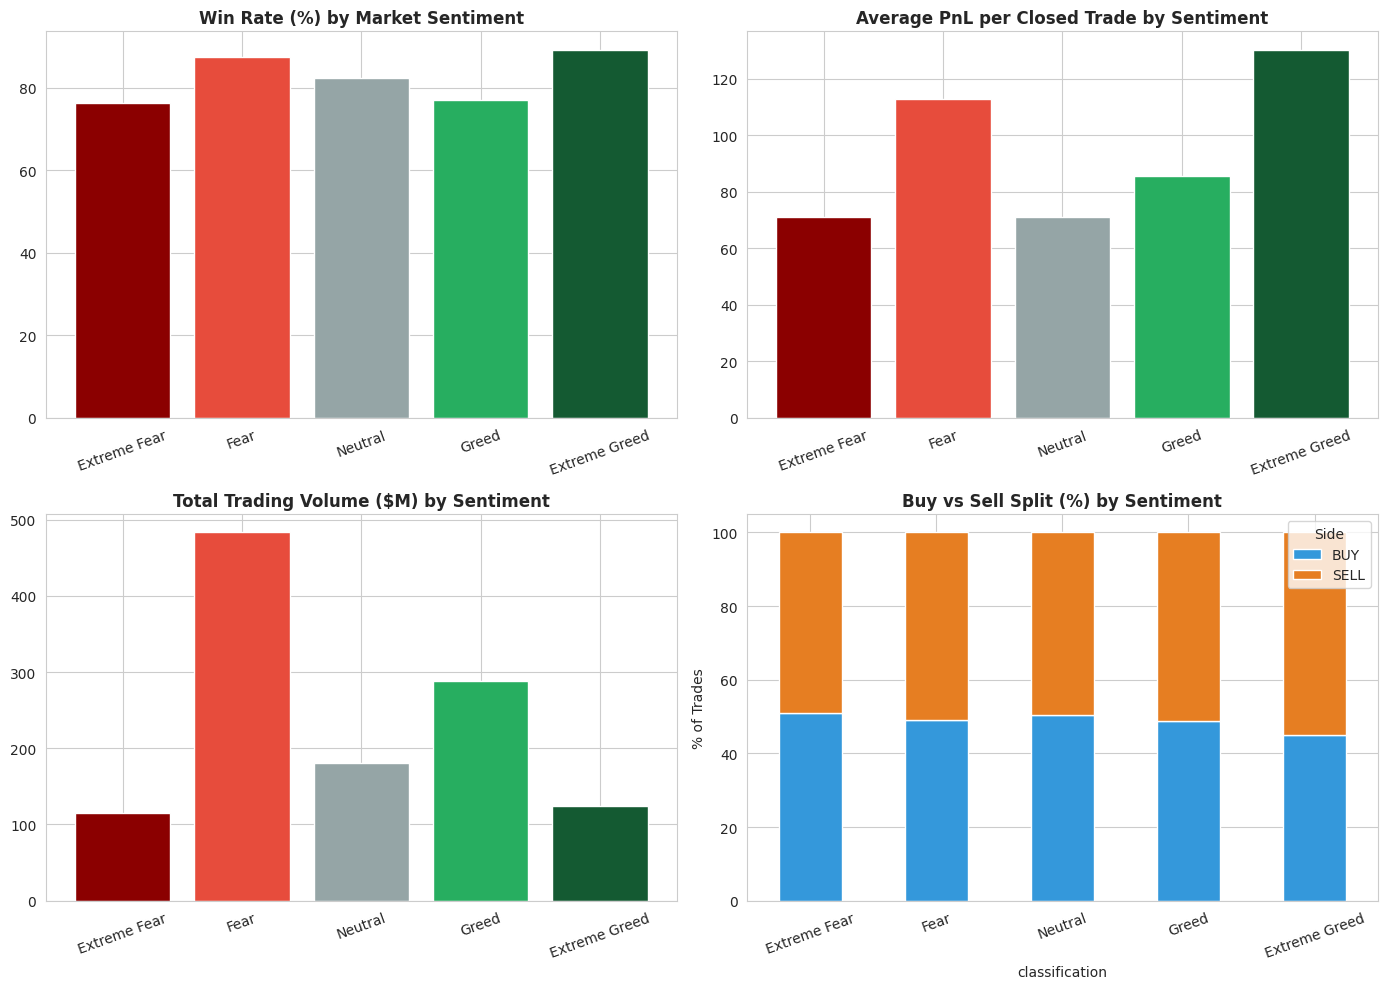

In [5]:
sns.set_style('whitegrid')
merged = pd.read_csv('merged_trades.csv')
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories = order,
                                          ordered=True)
closed=merged[merged['Closed PnL'] != 0].copy()
closed['classification']=pd.Categorical(closed['classification'], categories=order,
                                        ordered=True)
colors = ['#8B0000', '#E74C3C', '#95A5A6', '#27AE60', '#145A32']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

win_rate = closed.groupby('classification')['Closed PnL'].apply(lambda x: (x>0).mean()*100)
axes[0,0].bar(win_rate.index.astype(str), win_rate.values, color=colors)
axes[0,0].set_title('Win Rate (%) by Market Sentiment', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=20)

avg_pnl = closed.groupby('classification')['Closed PnL'].mean()
axes[0,1].bar(avg_pnl.index.astype(str), avg_pnl.values, color=colors)
axes[0,1].set_title('Average PnL per Closed Trade by Sentiment', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=20)

vol = merged.groupby('classification')['Size USD'].sum() / 1e6
axes[1,0].bar(vol.index.astype(str), vol.values, color=colors)
axes[1,0].set_title('Total Trading Volume ($M) by Sentiment', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

side_dist.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#3498DB','#E67E22'])
axes[1,1].set_title('Buy vs Sell Split (%) by Sentiment', fontweight='bold')
axes[1,1].set_ylabel('% of Trades')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].legend(title='Side')

plt.tight_layout()
plt.savefig('sentiment_analysis_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
pip install jupytext nbformat --break-system-packages -q 2>&1 | tail -3

Note: you may need to restart the kernel to use updated packages.
